In [2]:
!pip install -U pandas numpy scikit-learn xgboost shap matplotlib openpyxl



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import os, pandas as pd

TCRI_PATH = 'tcri.csv'
FIN_PATH  = 'ratios_filled_with_gics_category.csv'
OUT_DIR   = 'outputs/xgboost_model'

os.makedirs(OUT_DIR, exist_ok=True)
os.environ['OUT_DIR'] = OUT_DIR

print('tcri.csv exists?', os.path.exists(TCRI_PATH))
print('ratios_filled_with_gics_category.csv exists?', os.path.exists(FIN_PATH))


tcri.csv exists? True
ratios_filled_with_gics_category.csv exists? True


In [4]:
import os, pandas as pd
OUT_DIR = os.environ['OUT_DIR']

!python merge_tcri_and_ratios.py \
  --tcri "$TCRI_PATH" \
  --ratios "$FIN_PATH" \
  --ratios-date-format "%Y/%m" \
  --dedup-ratios \
  --out "$OUT_DIR/merged.csv"

merged = pd.read_csv(f"{OUT_DIR}/merged.csv", parse_dates=['mdate'])
merged.head()


[INFO] Dropped 88 duplicate rows from ratios data based on (id,date)
[INFO] Merged shape: (6383, 19). Saved to /Users/chieh.1227/repo/ML/outputs/xgboost_model/merged.csv


,coid,mdate,tcri,scr,xcdt,company,WorkingCapital_TotalAssets,RetainedEarnings_TotalAssets,CashFlow_TotalDebt,TotalDebt_TotalAssets,CurrentRatio,stock_prefix,WorkingCapital_TotalAssets_miss,RetainedEarnings_TotalAssets_miss,CashFlow_TotalDebt_miss,TotalDebt_TotalAssets_miss,CurrentRatio_miss,產業別,GICS_Category
0,1103,2014-12-01,6,400.0,NaN,1103 嘉泥,0.248834,0.222521,0.031686,0.355758,1.573942,11,0,0,0,0,0,水泥工業,9
1,1103,2015-12-01,6,432.0,NaN,1103 嘉泥,0.288490,0.266805,0.022494,0.396789,2.079358,11,0,0,0,0,0,水泥工業,9
2,1103,2016-12-01,6,371.0,NaN,1103 嘉泥,0.251213,0.276883,0.039433,0.332750,1.751954,11,0,0,0,0,0,水泥工業,9
3,1103,2017-12-01,6,330.0,NaN,1103 嘉泥,0.214906,0.277971,0.043575,0.277508,1.595351,11,0,0,0,0,0,水泥工業,9
4,1103,2018-12-01,6,331.0,NaN,1103 嘉泥,0.222120,0.264199,-0.055883,0.297109,1.501782,11,0,0,0,0,0,水泥工業,9


In [5]:

import os, json
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

from src.data_prep import load_and_prepare, create_label_next_period, time_split, detect_feature_columns
from src.metrics import best_f1_threshold, threshold_at_precision
from src.explain import run_shap_for_model
from src.modeling.logistic_pipeline import predict_with_calibration
from src.reporting import aggregate_slice_metrics, evaluate_predictions, prepare_prediction_frame, save_artifacts

CSV_PATH = os.path.join(os.environ['OUT_DIR'], 'merged.csv')
ID_COL = 'coid'
DATE_COL = 'mdate'
TCRI_COL = 'tcri'
GICS_COL = 'GICS_Category'
TAU = 7
HORIZON = 1
train_start, train_end = '2014-01-01', '2021-12-31'
valid_start, valid_end = '2022-01-01', '2022-12-31'
test_start, test_end = '2023-01-01', '2023-12-31'

df = load_and_prepare(CSV_PATH, ID_COL, DATE_COL, None, TCRI_COL)
df = create_label_next_period(df, ID_COL, TCRI_COL, TAU, HORIZON)
train, valid, test = time_split(df, DATE_COL, train_start, train_end, valid_start, valid_end, test_start, test_end)
num_cols, cat_cols = detect_feature_columns(train, ID_COL, DATE_COL, TCRI_COL, categorical_cols=[GICS_COL])

pre = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

param_grid = [
    {'max_depth':3, 'learning_rate':0.1, 'subsample':0.9, 'colsample_bytree':0.9},
    {'max_depth':4, 'learning_rate':0.05, 'subsample':0.8, 'colsample_bytree':0.8},
]

best_model = None
best_score = -np.inf
for params in param_grid:
    clf = XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        n_estimators=400,
        tree_method='hist',
        random_state=42,
        **params,
    )
    pipe = Pipeline([('pre', pre), ('clf', clf)])
    pipe.fit(train[num_cols + cat_cols], train['y'])
    p_valid = pipe.predict_proba(valid[num_cols + cat_cols])[:, 1]
    score = average_precision_score(valid['y'], p_valid)
    print(f'Params {params} -> PR-AUC(valid)={score:.4f}')
    if score > best_score:
        best_score = score
        best_model = pipe

print(f'[INFO] Best validation PR-AUC: {best_score:.4f}')

valid_features = valid[num_cols + cat_cols]
test_features = test[num_cols + cat_cols]
p_valid_best = best_model.predict_proba(valid_features)[:, 1]
t_f1 = best_f1_threshold(valid['y'].values, p_valid_best)
t_rp = threshold_at_precision(valid['y'].values, p_valid_best, 0.5)
print(f'[INFO] Thresholds: t_f1={t_f1:.4f}, t_at_precision={t_rp:.4f}')

probs = predict_with_calibration(best_model, valid_features, valid['y'], test_features)
metrics = evaluate_predictions(test['y'].values, probs, threshold=t_f1, target_precision=0.5)
metrics['thresholds'] = {'t_f1': t_f1, 't_at_precision': t_rp, 'precision_target': 0.5}
metrics['valid_pr_auc_for_best_params'] = float(best_score)

slice_tables = {
    'quarter': aggregate_slice_metrics(test, probs, 'quarter', threshold=t_f1, target_precision=0.5),
}
if GICS_COL in test.columns:
    slice_tables[GICS_COL] = aggregate_slice_metrics(test, probs, GICS_COL, threshold=t_f1, target_precision=0.5)

feature_names = best_model.named_steps['pre'].get_feature_names_out()
importances = best_model.named_steps['clf'].feature_importances_
feature_weights = pd.DataFrame({
    'feature': feature_names,
    'coefficient': importances,
    'abs_coefficient': np.abs(importances),
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

preds = prepare_prediction_frame(test, ID_COL, DATE_COL, probs)
save_artifacts(preds, metrics, feature_weights, slice_tables, os.environ['OUT_DIR'])

print(json.dumps(metrics['raw'], indent=2))
print('Artifacts saved to', os.environ['OUT_DIR'])

pretrained = best_model.named_steps['clf']
dense_train = best_model.named_steps['pre'].transform(train[num_cols + cat_cols])
dense_test = best_model.named_steps['pre'].transform(test[num_cols + cat_cols])
run_shap_for_model(
    fitted_model=pretrained,
    X_train=dense_train,
    X_test=dense_test,
    feature_names=feature_weights['feature'].tolist(),
    model_name='xgboost_model'
)


/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Params {'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9} -> PR-AUC(valid)=0.7773
Params {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8} -> PR-AUC(valid)=0.7734
[INFO] Best validation PR-AUC: 0.7773
[INFO] Thresholds: t_f1=0.2600, t_at_precision=0.0865


/Users/chieh.1227/repo/ML/.venv/lib/python3.12/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


{
  "pr_auc": 0.6864379342654539,
  "roc_auc": 0.8222447943118334,
  "f1": 0.636144578313253,
  "precision": 0.559322033898305,
  "recall": 0.7374301675977654,
  "brier": 0.15006473674630266,
  "logloss": 0.485935150888536,
  "ece": 0.07606056814649184,
  "threshold": 0.2600458860397339,
  "recall_at_p>=0.50": 0.8156424581005587,
  "threshold_at_p>=0.50": 0.17915409803390503
}
Artifacts saved to outputs/xgboost_model


In [6]:
import os, json, pandas as pd
OUT_DIR = os.environ['OUT_DIR']
with open(f'{OUT_DIR}/metrics_summary.json', 'r', encoding='utf-8') as f:
    summary = json.load(f)
summary

pd.read_csv(f'{OUT_DIR}/metrics_by_quarter.csv').head()


,slice,n,pos,raw.pr_auc,raw.roc_auc,raw.f1,raw.precision,raw.recall,raw.brier,raw.logloss,...,platt.roc_auc,platt.f1,platt.precision,platt.recall,platt.brier,platt.logloss,platt.ece,platt.threshold,platt.recall_at_p>=0.50,platt.threshold_at_p>=0.50
0,quarter=2023Q4,619,179,0.686438,0.822245,0.636145,0.559322,0.73743,0.150065,0.485935,...,0.822245,0.637681,0.561702,0.73743,0.149924,0.469593,0.063757,0.260046,0.815642,0.190289


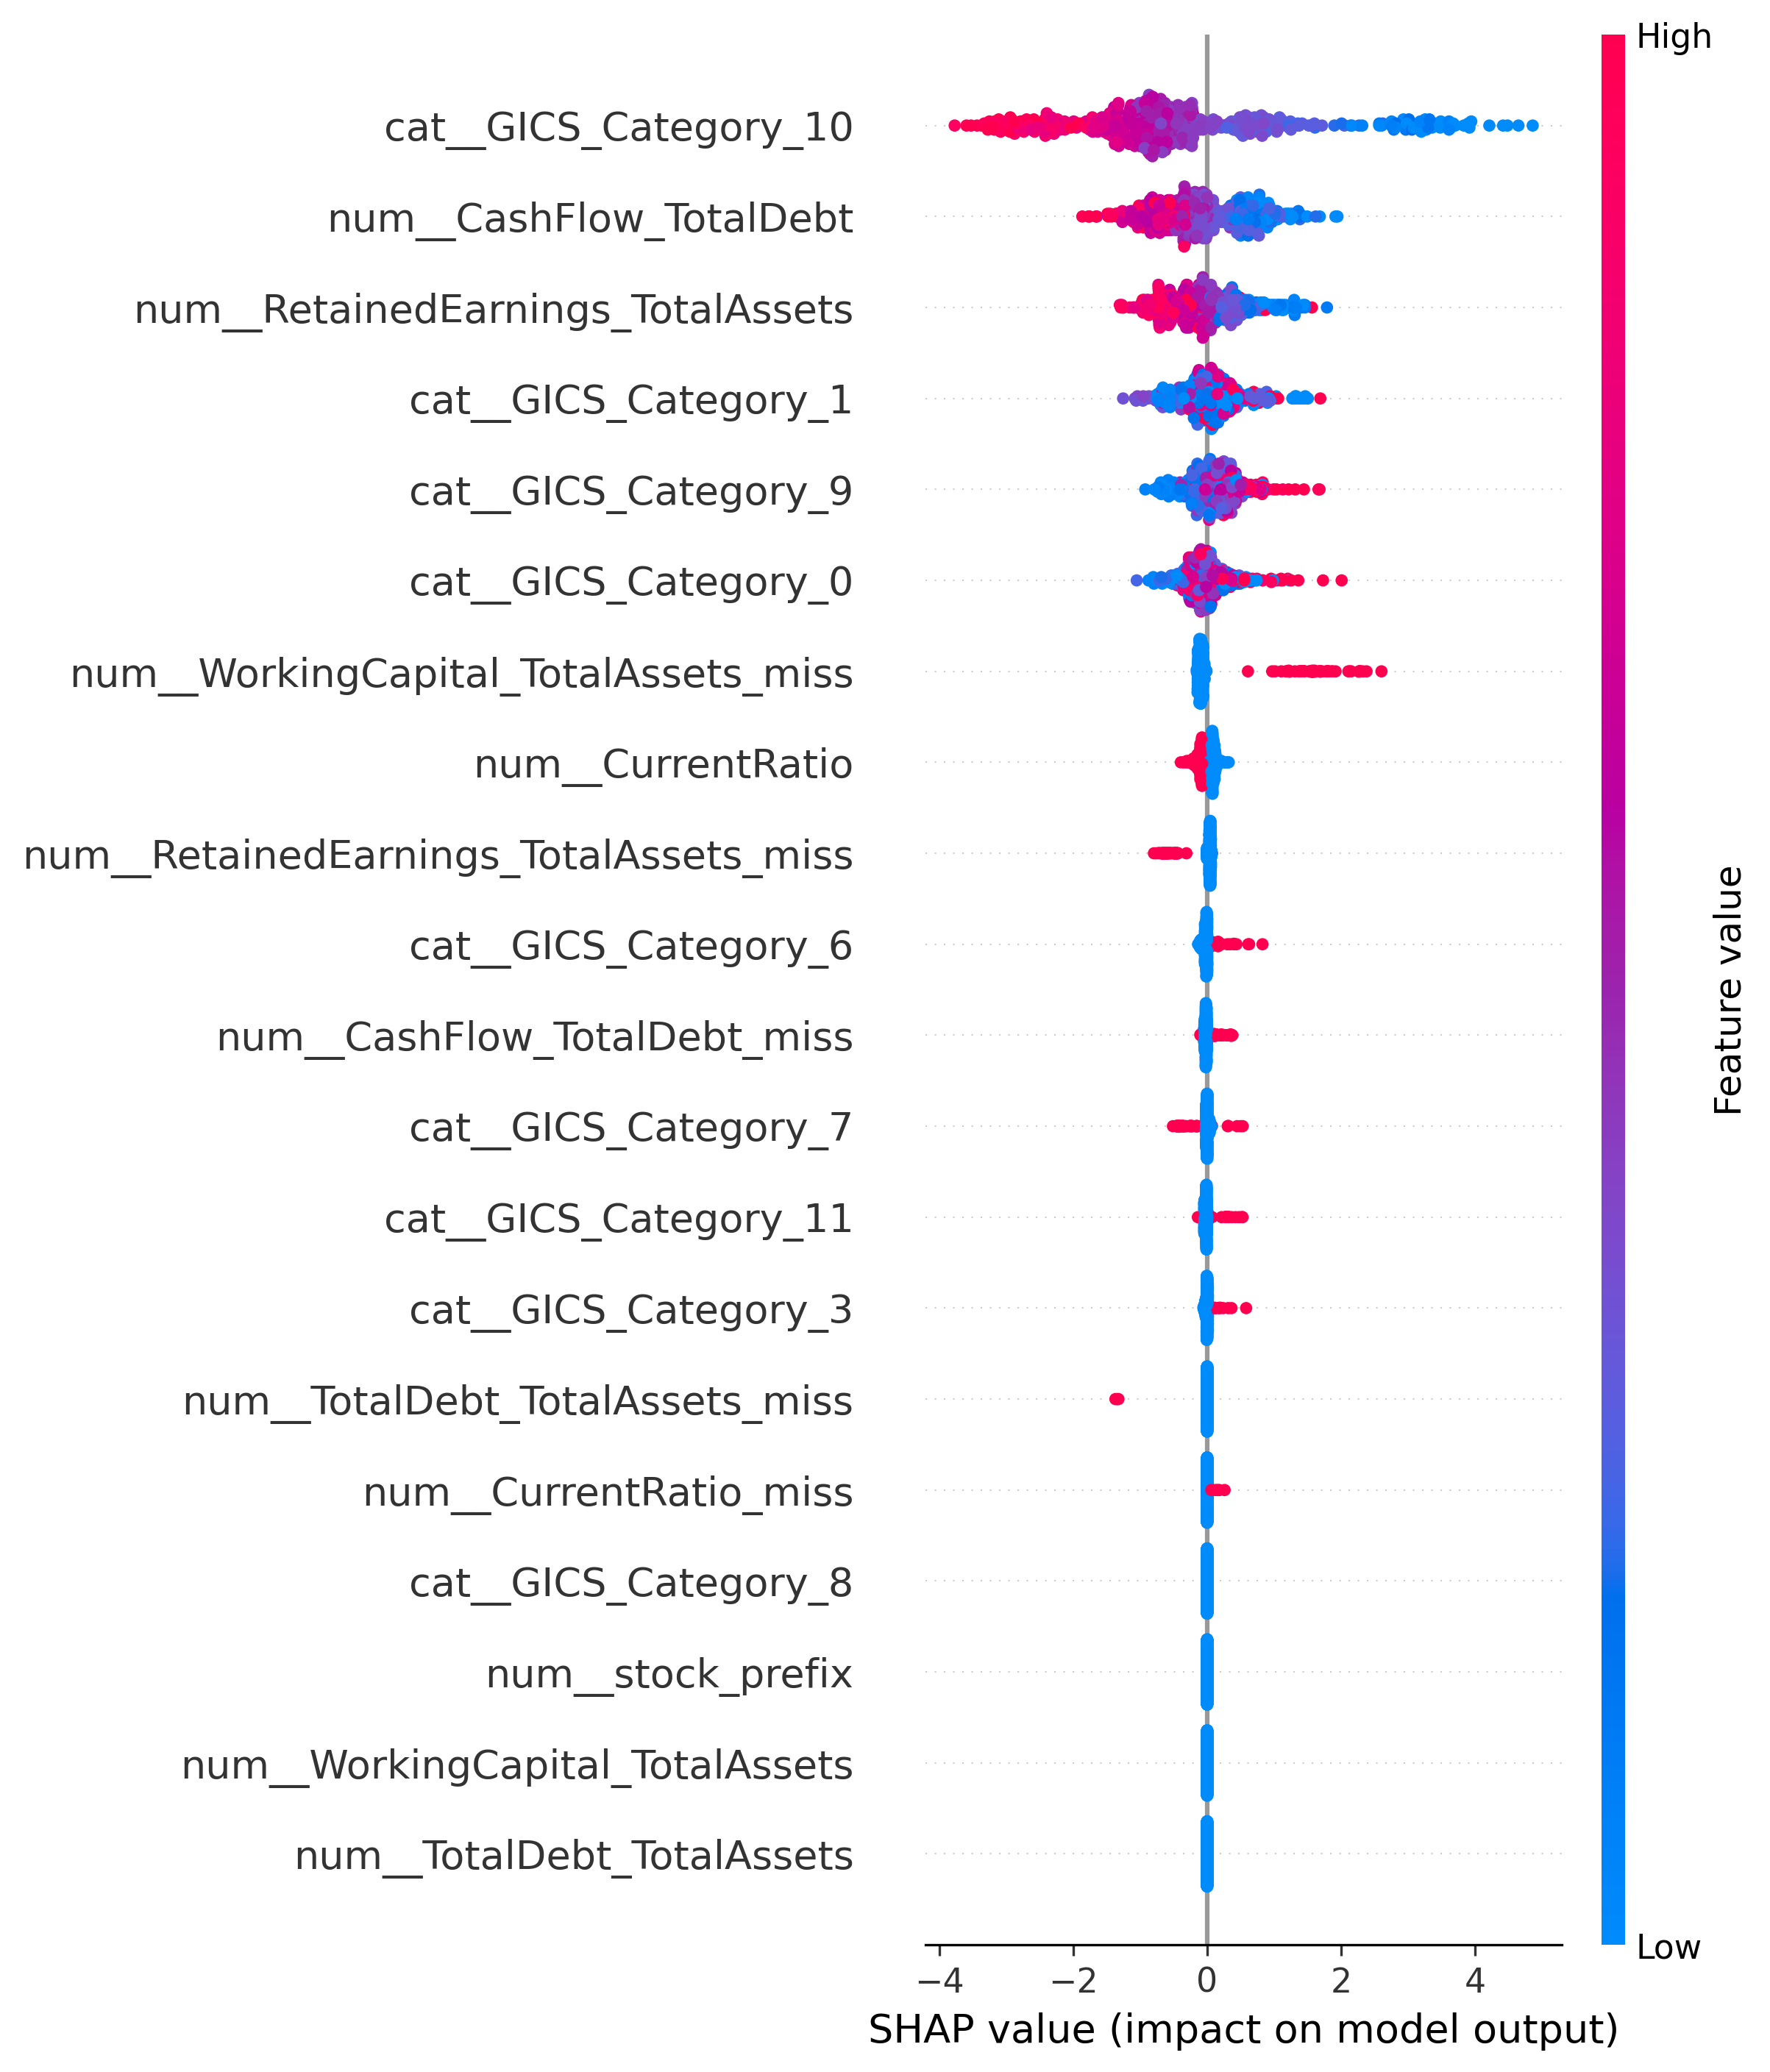

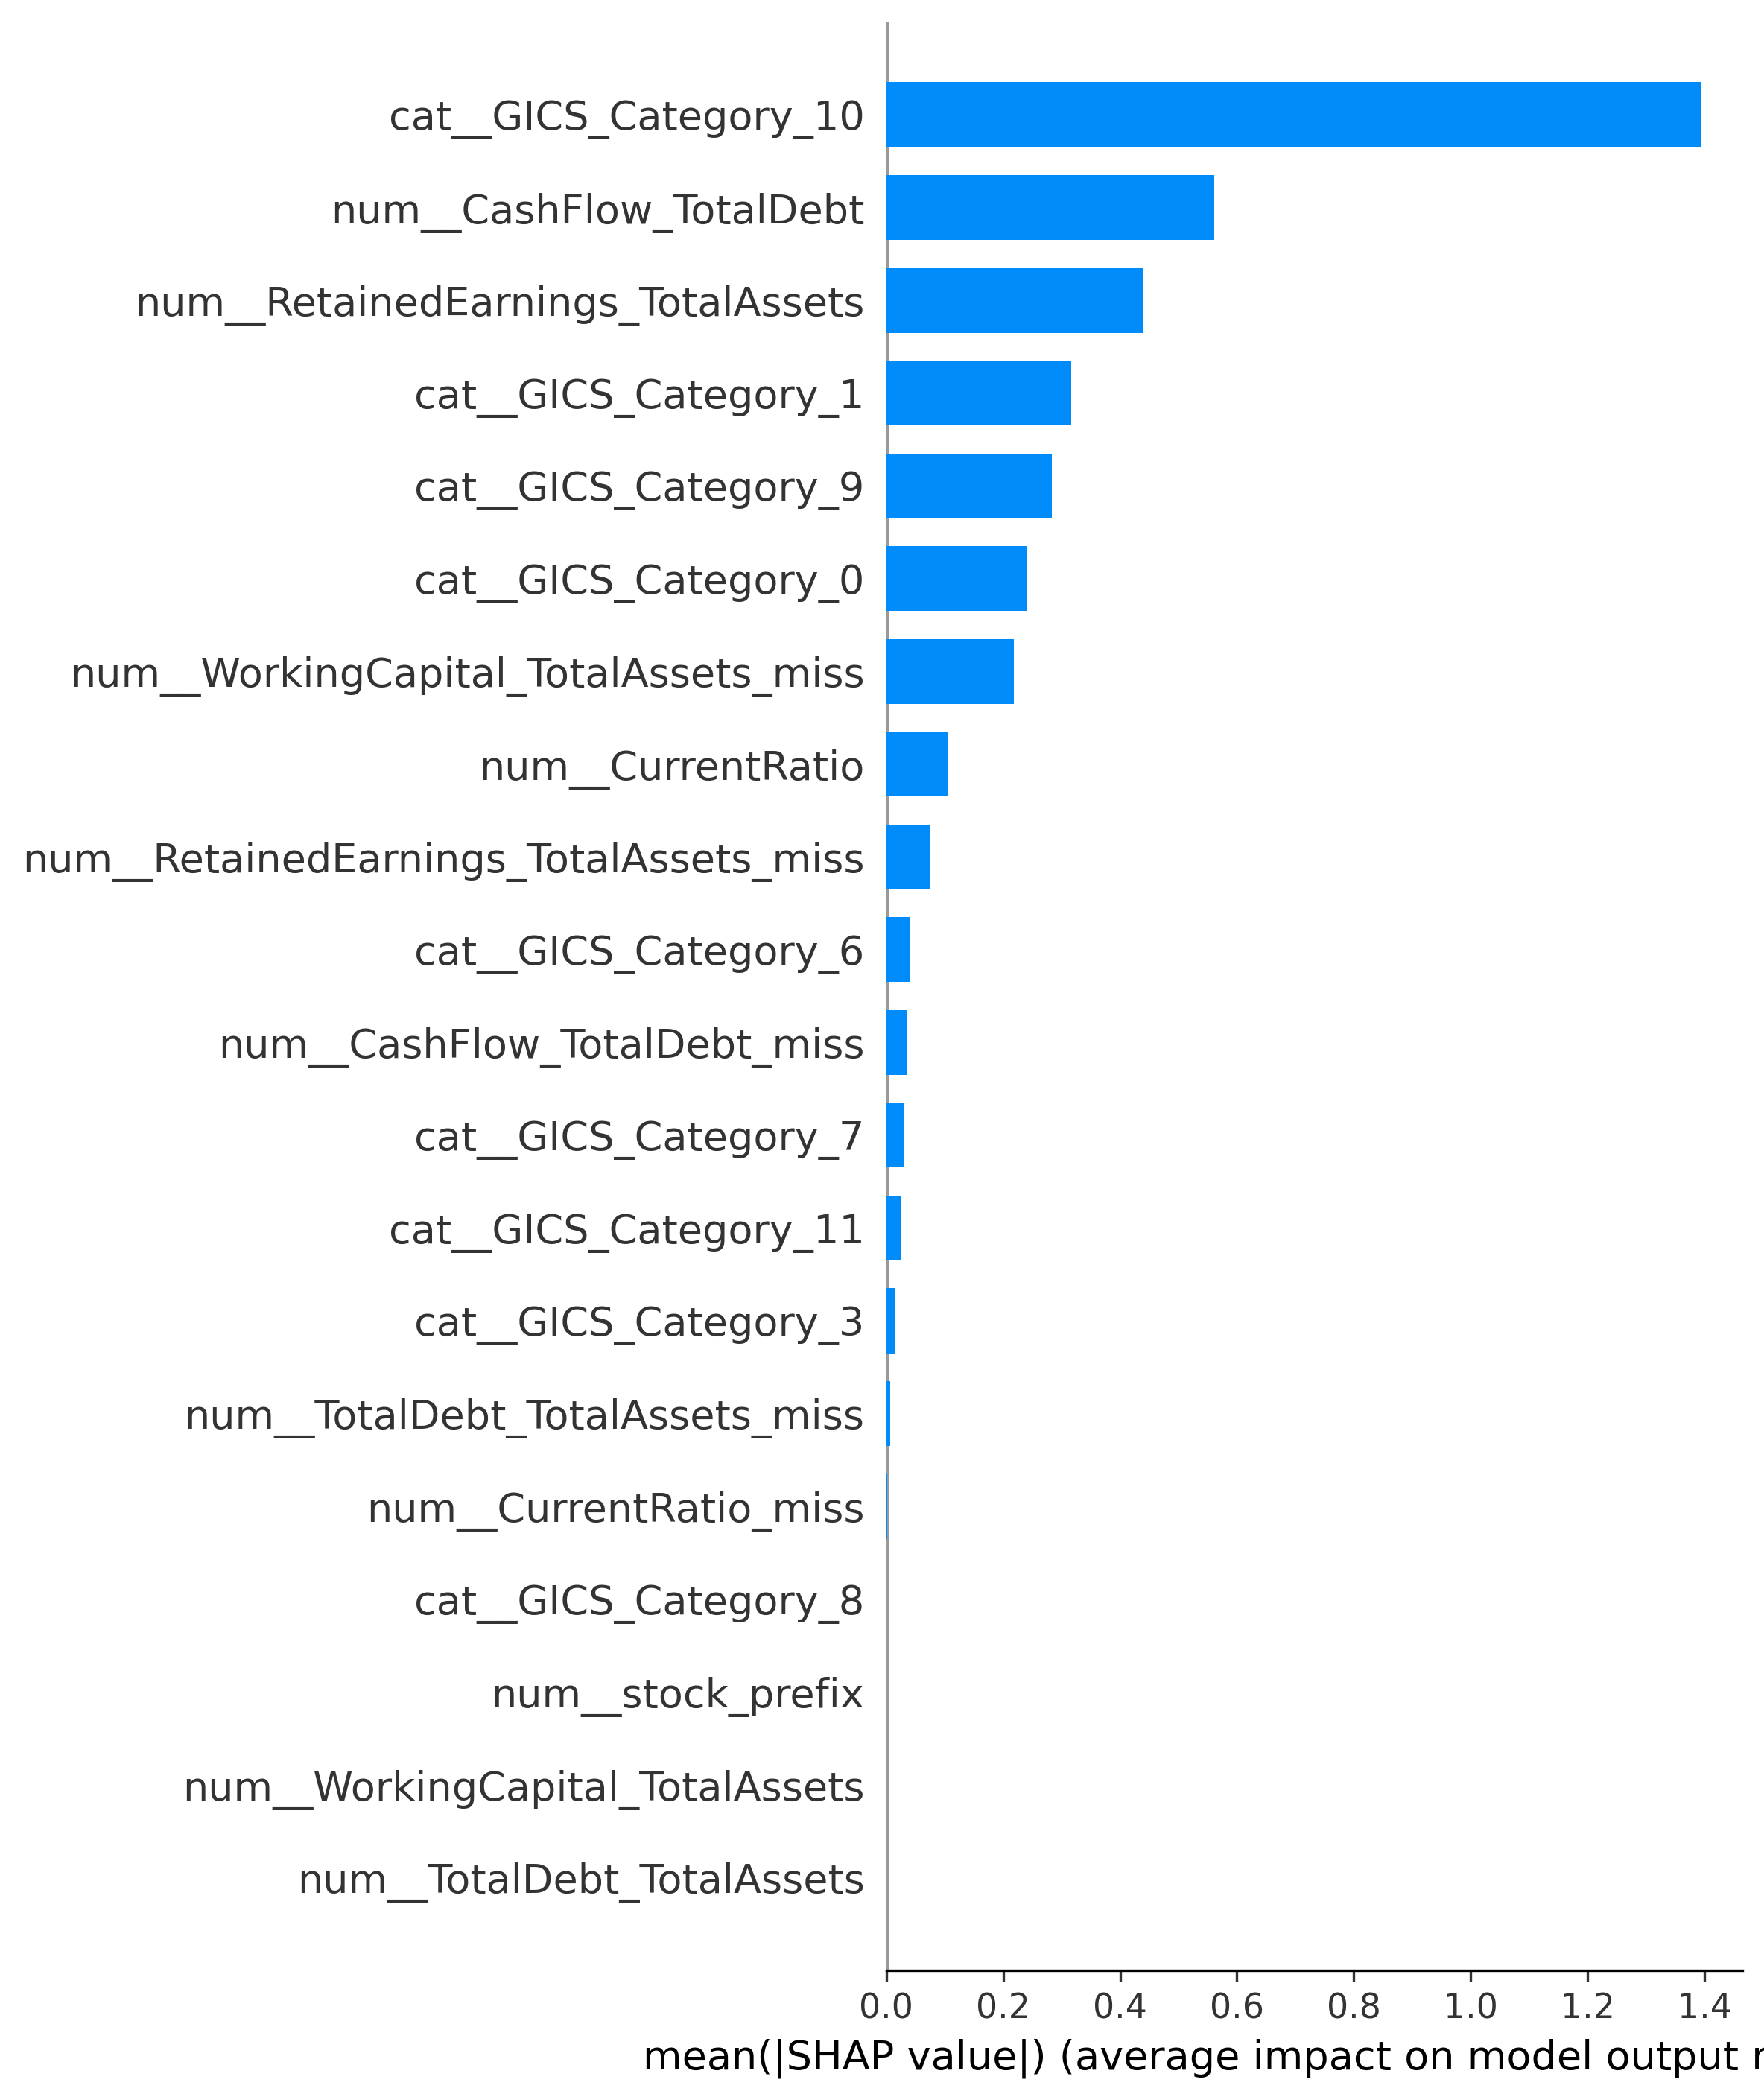

In [7]:
from IPython.display import Image
display(Image(filename='outputs/plots/shap_summary_xgboost_model.png'))
display(Image(filename='outputs/plots/shap_bar_xgboost_model.png'))


In [8]:
import os, json, pandas as pd
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/xgboost_model')
with open(f'{OUT_DIR}/metrics_summary.json','r',encoding='utf-8') as f:
    metrics_summary = json.load(f)
pd.DataFrame({k:v for k,v in metrics_summary.items() if isinstance(v,dict) and 'pr_auc' in v}).T


,pr_auc,roc_auc,f1,precision,recall,brier,logloss,ece,threshold,recall_at_p>=0.50,threshold_at_p>=0.50
raw,0.686438,0.822245,0.636145,0.559322,0.73743,0.150065,0.485935,0.076061,0.260046,0.815642,0.179154
platt,0.686438,0.822245,0.637681,0.561702,0.73743,0.149924,0.469593,0.063757,0.260046,0.815642,0.190289


In [9]:
import os, pandas as pd
OUT_DIR = os.environ.get('OUT_DIR', 'outputs/xgboost_model')
threshold = metrics_summary['thresholds']['t_f1']
preds = pd.read_csv(f'{OUT_DIR}/predictions_test.csv')
preds['y_pred_raw'] = (preds['p_raw'] >= threshold).astype(int)
confusion = pd.crosstab(preds['y_true'], preds['y_pred_raw'], rownames=['y_true'], colnames=['y_pred'])
confusion = confusion.reindex(index=[0,1], columns=[0,1], fill_value=0)
confusion


y_pred,0,1
y_true,,
0,336,104
1,47,132
